In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv("ToyotaCorolla - MLR.csv")

print(df.head())

   Price  Age_08_04     KM Fuel_Type  HP  Automatic    cc  Doors  Cylinders  \
0  13500         23  46986    Diesel  90          0  2000      3          4   
1  13750         23  72937    Diesel  90          0  2000      3          4   
2  13950         24  41711    Diesel  90          0  2000      3          4   
3  14950         26  48000    Diesel  90          0  2000      3          4   
4  13750         30  38500    Diesel  90          0  2000      3          4   

   Gears  Weight  
0      5    1165  
1      5    1165  
2      5    1165  
3      5    1165  
4      5    1170  


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null   int64 
 6   cc         1436 non-null   int64 
 7   Doors      1436 non-null   int64 
 8   Cylinders  1436 non-null   int64 
 9   Gears      1436 non-null   int64 
 10  Weight     1436 non-null   int64 
dtypes: int64(10), object(1)
memory usage: 123.5+ KB


In [8]:
print(df.shape)

(1436, 11)


In [9]:
print(df.isnull().sum())

Price        0
Age_08_04    0
KM           0
Fuel_Type    0
HP           0
Automatic    0
cc           0
Doors        0
Cylinders    0
Gears        0
Weight       0
dtype: int64


In [10]:
print(df.describe())

              Price    Age_08_04             KM           HP    Automatic  \
count   1436.000000  1436.000000    1436.000000  1436.000000  1436.000000   
mean   10730.824513    55.947075   68533.259749   101.502089     0.055710   
std     3626.964585    18.599988   37506.448872    14.981080     0.229441   
min     4350.000000     1.000000       1.000000    69.000000     0.000000   
25%     8450.000000    44.000000   43000.000000    90.000000     0.000000   
50%     9900.000000    61.000000   63389.500000   110.000000     0.000000   
75%    11950.000000    70.000000   87020.750000   110.000000     0.000000   
max    32500.000000    80.000000  243000.000000   192.000000     1.000000   

                cc        Doors  Cylinders        Gears      Weight  
count   1436.00000  1436.000000     1436.0  1436.000000  1436.00000  
mean    1576.85585     4.033426        4.0     5.026462  1072.45961  
std      424.38677     0.952677        0.0     0.188510    52.64112  
min     1300.00000     2.0

In [11]:

print(df["Fuel_Type"].value_counts())

Fuel_Type
Petrol    1264
Diesel     155
CNG         17
Name: count, dtype: int64


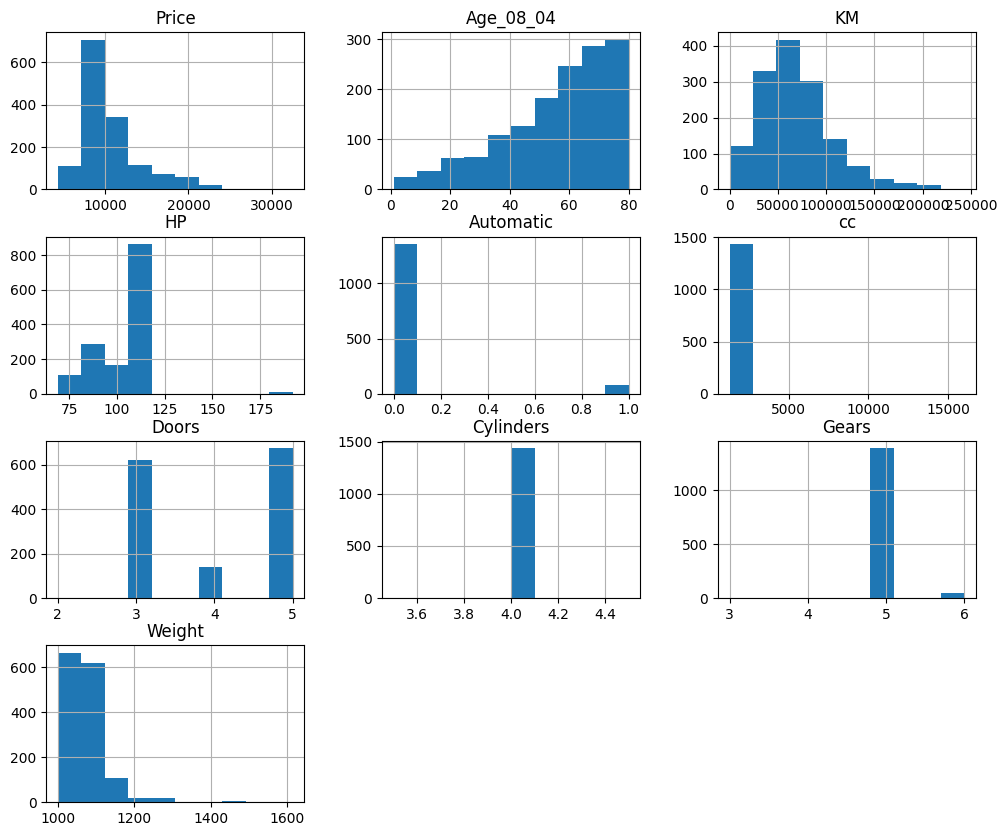

In [12]:

df.hist(figsize=(12,10))

plt.show()

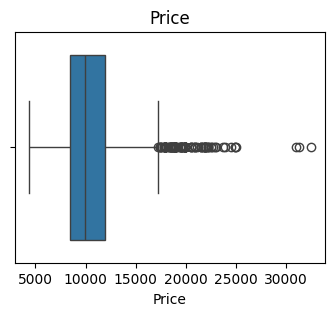

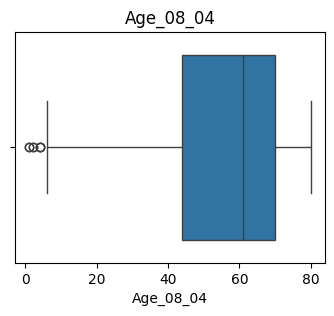

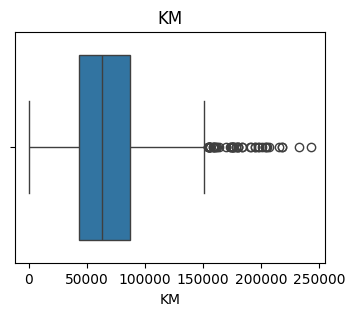

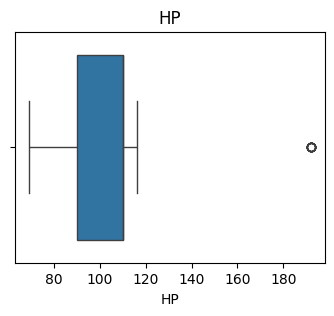

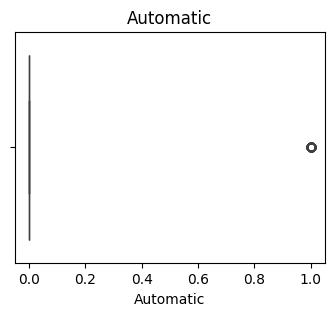

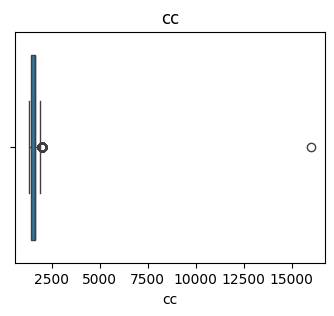

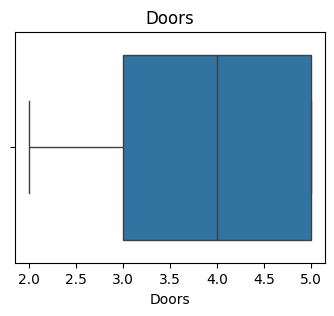

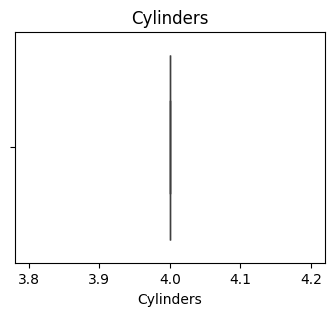

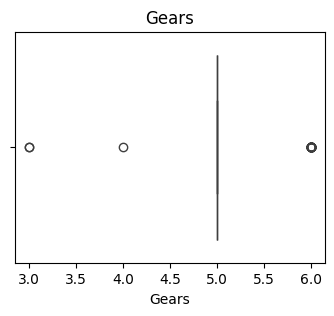

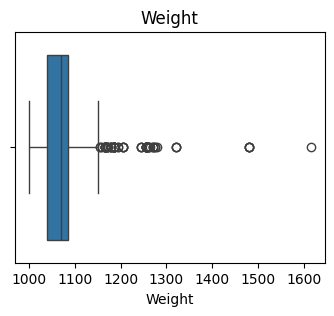

In [13]:
# Boxplots

for col in df.select_dtypes(include=np.number).columns:

    plt.figure(figsize=(4,3))

    sns.boxplot(x=df[col])

    plt.title(col)

    plt.show()

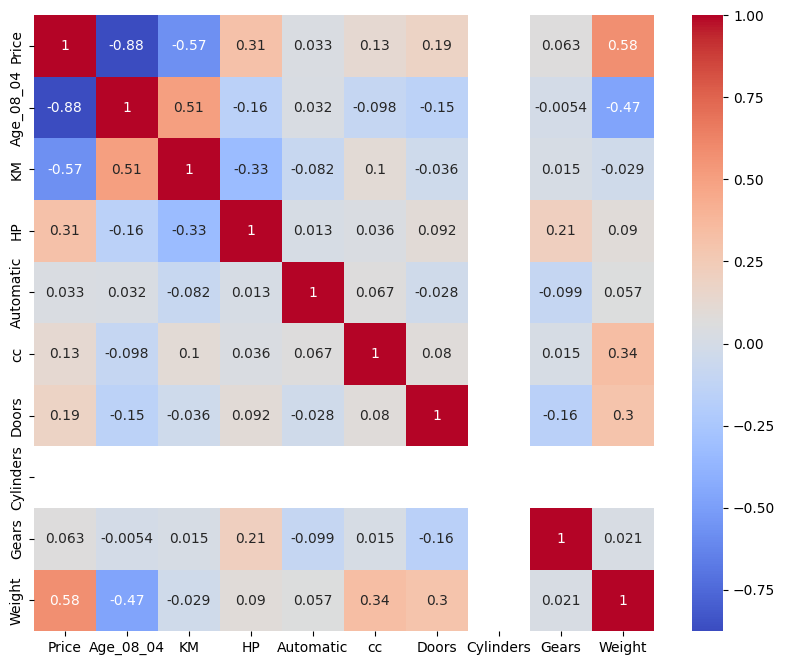

In [14]:
# Correlation heatmap

plt.figure(figsize=(10,8))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")

plt.show()

In [15]:
# Converting categorical column into numerical values

df = pd.get_dummies(df,
                    columns=["Fuel_Type"],
                    drop_first=True)

print(df.head())

   Price  Age_08_04     KM  HP  Automatic    cc  Doors  Cylinders  Gears  \
0  13500         23  46986  90          0  2000      3          4      5   
1  13750         23  72937  90          0  2000      3          4      5   
2  13950         24  41711  90          0  2000      3          4      5   
3  14950         26  48000  90          0  2000      3          4      5   
4  13750         30  38500  90          0  2000      3          4      5   

   Weight  Fuel_Type_Diesel  Fuel_Type_Petrol  
0    1165              True             False  
1    1165              True             False  
2    1165              True             False  
3    1165              True             False  
4    1170              True             False  


In [16]:
# Checking final dataset

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Price             1436 non-null   int64
 1   Age_08_04         1436 non-null   int64
 2   KM                1436 non-null   int64
 3   HP                1436 non-null   int64
 4   Automatic         1436 non-null   int64
 5   cc                1436 non-null   int64
 6   Doors             1436 non-null   int64
 7   Cylinders         1436 non-null   int64
 8   Gears             1436 non-null   int64
 9   Weight            1436 non-null   int64
 10  Fuel_Type_Diesel  1436 non-null   bool 
 11  Fuel_Type_Petrol  1436 non-null   bool 
dtypes: bool(2), int64(10)
memory usage: 115.1 KB
None


In [17]:
# EDA Findings:
#
# The dataset contains information about Toyota Corolla cars.
#
# Numerical variables were analyzed using summary statistics,
# histograms and boxplots.
#
# Fuel_Type was converted into numerical format using
# dummy variables.
#
# Correlation heatmap was used to understand relationships
# between variables before building the regression model.

In [18]:
#TASK 2
X = df.drop("Price", axis=1)

y = df["Price"]

In [19]:
# Splitting dataset into training and testing sets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(1148, 11)
(288, 11)


In [20]:
# creating a linear model

from sklearn.linear_model import LinearRegression

model1 = LinearRegression()

model1.fit(X_train, y_train)

LinearRegression()

In [21]:

y_pred1 = model1.predict(X_test)

print(y_pred1[:5])

[11137.15453645  8974.9731327   9283.27025955  8951.97440751
 10082.31592852]


In [22]:
# Evaluating model

from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

print("R2 Score =", r2_score(y_test, y_pred1))

print("MAE =", mean_absolute_error(y_test, y_pred1))

print("MSE =", mean_squared_error(y_test, y_pred1))

R2 Score = 0.8348888040611082
MAE = 990.8872739193926
MSE = 2203043.8231437025


In [23]:
# Creating second model with selected features

X2 = df[["Age_08_04", "KM", "HP"]]

y = df["Price"]

In [24]:

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2,
    y,
    test_size=0.20,
    random_state=42
)

In [25]:

model2 = LinearRegression()

model2.fit(X_train2, y_train2)

LinearRegression()

In [26]:

y_pred2 = model2.predict(X_test2)

print("R2 Score =", r2_score(y_test2, y_pred2))

print("MAE =", mean_absolute_error(y_test2, y_pred2))

print("MSE =", mean_squared_error(y_test2, y_pred2))

R2 Score = 0.8103259513824549
MAE = 1111.541780060628
MSE = 2530780.7798339287


In [27]:
# Creating third model

X3 = df[["Age_08_04", "KM", "HP", "Weight"]]

y = df["Price"]

In [28]:

X_train3, X_test3, y_train3, y_test3 = train_test_split(
    X3,
    y,
    test_size=0.20,
    random_state=42
)

In [29]:

model3 = LinearRegression()

model3.fit(X_train3, y_train3)

LinearRegression()

In [30]:


y_pred3 = model3.predict(X_test3)

print("R2 Score =", r2_score(y_test3, y_pred3))

print("MAE =", mean_absolute_error(y_test3, y_pred3))

print("MSE =", mean_squared_error(y_test3, y_pred3))

R2 Score = 0.8506068681500583
MAE = 1001.2017466053621
MSE = 1993321.0129730713


In [31]:
# Applying Ridge Regression

from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)

ridge.fit(X_train, y_train)

ridge_pred = ridge.predict(X_test)

print("R2 Score =", r2_score(y_test, ridge_pred))

R2 Score = 0.8351359377712336


In [32]:
# Applying Lasso Regression

from sklearn.linear_model import Lasso

lasso = Lasso(alpha=1.0)

lasso.fit(X_train, y_train)

lasso_pred = lasso.predict(X_test)

print("R2 Score =", r2_score(y_test, lasso_pred))

R2 Score = 0.8354626403967389


Interview Question 1

 Normalization:
 Scales data between 0 and 1.

 Standardization:
 Converts data to mean 0 and standard deviation 1.

 These methods help improve model performance
 when features have different scales.

Interview Question 2

 Techniques to handle multicollinearity:

 1. Remove highly correlated variables.
 2. Use Ridge Regression.
 3. Use Lasso Regression.